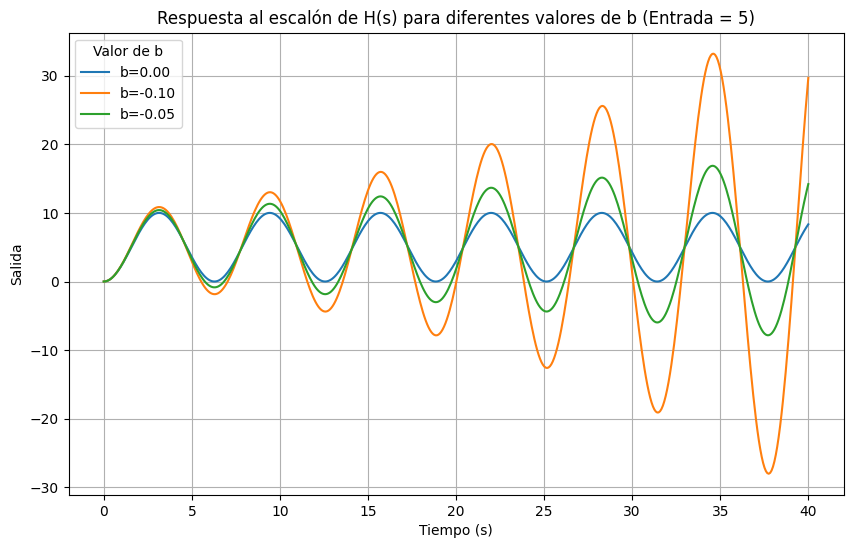

Las respuestas al escalón para diferentes valores de 'b' han sido simuladas y graficadas.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import TransferFunction, step

# 1. Definir un array de tiempo para la simulación
t = np.linspace(0, 40, 500)  # De 0 a 20 segundos, 500 puntos

# 2. Crear una figura vacía para el gráfico
plt.figure(figsize=(10, 6))

# 3. Rango de b para las simulaciones

b = [0, -0.1, -0.05 ]


for b_val in b:
    # 4. Definir los coeficientes del numerador y denominador para H(s) = 1/(s^2 + b*s + 1)
    num = [1]
    den = [1, b_val, 1]

    # 5. Crear el objeto de función de transferencia
    sys = TransferFunction(num, den)

    # 6. Calcular la respuesta al escalón
    tout, yout = step(sys, T=t)

    # 7. Multiplicar los valores de la respuesta al escalón por la magnitud de la entrada (5)
    yout_scaled = yout * 5

    # 8. Graficar la respuesta en el tiempo resultante
    plt.plot(tout, yout_scaled, label=f'b={b_val:.2f}')


plt.title('Respuesta al escalón de H(s) para diferentes valores de b (Entrada = 5)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Salida')
plt.legend(title='Valor de b')
plt.grid(True)
plt.savefig('sistema.pdf')
plt.show()


print("Las respuestas al escalón para diferentes valores de 'b' han sido simuladas y graficadas.")

## Lugar de las Raíces y Ubicación de los Polos

El diagrama del lugar de las raíces (root locus) es una herramienta gráfica que muestra cómo se mueven las raíces de la ecuación característica (es decir, los polos del sistema) en el plano complejo a medida que un parámetro del sistema varía. En este caso, veremos cómo los polos de la función de transferencia $H(s) = \frac{1}{s^2 - b s + 1}$ cambian a medida que el valor de 'b' (el coeficiente de amortiguamiento) se modifica.

Los polos son las raíces de la ecuación $s^2 - b s + 1 = 0$, que se pueden encontrar usando la fórmula cuadrática

*   Si $b > 0$, los polos son inestables
La siguiente gráfica mostrará el camino general que siguen los polos y destacará las ubicaciones específicas de los polos para los valores de 'b' que hemos analizado en el computador analógico.


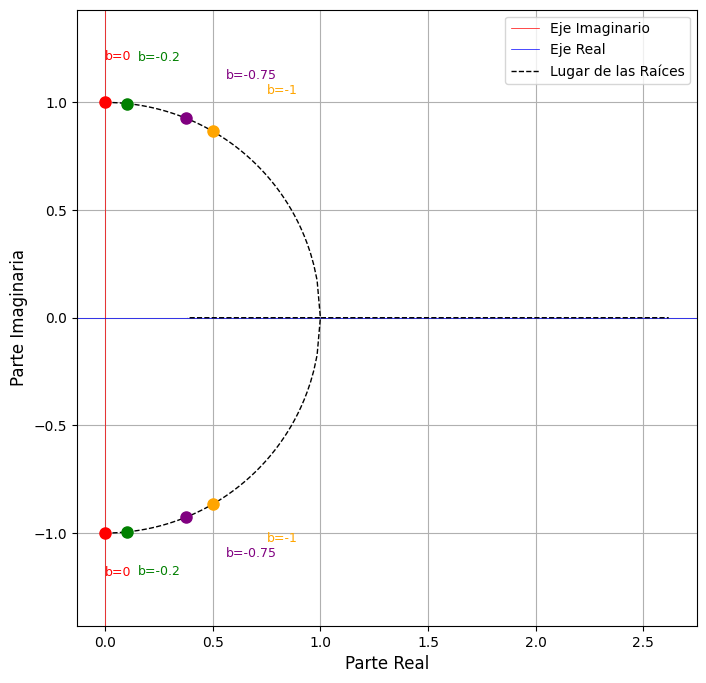

El diagrama del lugar de las raíces y la ubicación de los polos para diferentes valores de 'b' ha sido generado.


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Define una gama más amplia de valores de 'b' para visualizar el camino del lugar de las raíces
b_locus_range = np.linspace(0, -3, 100) # 100 puntos desde 0 hasta 3 para una buena resolución

plt.figure(figsize=(8, 8))
plt.axvline(x=0, color='red', linestyle='-', linewidth=0.5, label='Eje Imaginario') # Eje Imaginario
plt.axhline(y=0, color='blue', linestyle='-', linewidth=0.5, label='Eje Real')    # Eje Real

# Listas para almacenar los polos para trazar el lugar de las raíces como líneas
locus_poles_real_pos = []
locus_poles_imag_pos = []
locus_poles_real_neg = []
locus_poles_imag_neg = []

for b_val in b_locus_range:
    # Calcular los polos para s^2 + b*s + 1 = 0
    poles = np.roots([1, b_val, 1])

    # Asegurarse de que la parte imaginaria positiva esté en la primera lista y la negativa en la segunda
    if poles[0].imag >= 0:
        locus_poles_real_pos.append(poles[0].real)
        locus_poles_imag_pos.append(poles[0].imag)
        locus_poles_real_neg.append(poles[1].real)
        locus_poles_imag_neg.append(poles[1].imag)
    else:
        locus_poles_real_pos.append(poles[1].real)
        locus_poles_imag_pos.append(poles[1].imag)
        locus_poles_real_neg.append(poles[0].real)
        locus_poles_imag_neg.append(poles[0].imag)

# Trazar el camino del lugar de las raíces como una línea continua
plt.plot(locus_poles_real_pos, locus_poles_imag_pos, 'k--', linewidth=1, label='Lugar de las Raíces')
plt.plot(locus_poles_real_neg, locus_poles_imag_neg, 'k--', linewidth=1)

# Ahora, trazar los valores específicos de 'b' utilizados en los cálculos anteriores
specific_b_values = [0,  -0.2, -0.75, -1]
colors = ['red', 'green', 'purple', 'orange', 'blue']

for i, b_val in enumerate(specific_b_values):
    poles = np.roots([1, b_val, 1])
    # Trazar estos polos específicos con marcadores y etiquetas distintos
    for pole in poles:
        plt.plot(pole.real, pole.imag, 'o', markersize=8, color=colors[i], zorder=5) # zorder asegura que se dibuje encima
        # Añadir una etiqueta de texto junto al polo
        plt.text(1.5*pole.real , 1.2* pole.imag, f'b={b_val}', color=colors[i], fontsize=9)


#plt.title('Lugar de las Raíces para $H(s) = \frac{1}{s^2 + b s + 1}$', fontsize=14)

plt.xlabel('Parte Real', fontsize=12)
plt.ylabel('Parte Imaginaria', fontsize=12)
plt.grid(True)
plt.axis('equal') # Asegurar que los ejes real e imaginario tengan la misma escala
plt.legend()
plt.show()

print("El diagrama del lugar de las raíces y la ubicación de los polos para diferentes valores de 'b' ha sido generado.")